# SteamScope：数据清洗与特征工程

本 Notebook 是 SteamScope 项目的第三个 Notebook，回答的问题是：**如何把原始 Steam CSV 表格转换成可靠的分析数据资产？**

前两个 Notebook 已经完成了数据集概览和大表格处理策略比较。本 Notebook 将进一步完成字段统一、缺失值检查、重复值检查、异常值检查、多标签字段清洗和基础特征工程，并输出后续市场结构分析与玩家反馈分析可以复用的数据文件。

## 1. 环境与数据读取

本节读取 Notebook 02 生成的核心字段 Parquet 文件。如果该文件不存在，则回退到原始 CSV 进行选列读取。为了后续分析更完整，这里还会补充读取部分文本字段和多标签字段。

In [1]:
from pathlib import Path
import ast
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", context="notebook")
plt.style.use("seaborn-v0_8-whitegrid")

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "archive"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MAIN_CSV = RAW_DIR / "games_march2025_cleaned.csv"
COMPARE_CSV = RAW_DIR / "games_may2024_cleaned.csv"
SELECTED_PARQUET = PROCESSED_DIR / "steam_march2025_selected.parquet"
FEATURE_PARQUET = PROCESSED_DIR / "steam_march2025_features.parquet"
FEATURE_CSV = PROCESSED_DIR / "steam_march2025_features_sample.csv"
QUALITY_REPORT = PROCESSED_DIR / "steam_data_quality_report.csv"

base_columns = [
    "appid", "name", "release_date", "required_age", "price", "discount", "dlc_count",
    "windows", "mac", "linux", "metacritic_score", "achievements", "recommendations",
    "developers", "publishers", "categories", "genres", "user_score", "positive", "negative",
    "estimated_owners", "average_playtime_forever", "average_playtime_2weeks",
    "median_playtime_forever", "median_playtime_2weeks", "peak_ccu", "tags",
    "pct_pos_total", "num_reviews_total", "pct_pos_recent", "num_reviews_recent",
    "supported_languages", "full_audio_languages", "short_description", "about_the_game",
]

if SELECTED_PARQUET.exists():
    selected_df = pd.read_parquet(SELECTED_PARQUET)
    print(f"读取 Notebook 02 生成的 Parquet：{SELECTED_PARQUET}")
else:
    selected_cols = [col for col in base_columns if col in pd.read_csv(MAIN_CSV, nrows=0).columns]
    selected_df = pd.read_csv(MAIN_CSV, usecols=selected_cols)
    print(f"Parquet 不存在，回退读取 CSV：{MAIN_CSV}")

# selected Parquet 只含核心字段，因此这里用 Polars 按需读取剩余字段，避免整表 Pandas 读取长文本
available_columns = pd.read_csv(MAIN_CSV, nrows=0).columns.tolist()
read_columns = [col for col in base_columns if col in available_columns]
raw_df = pl.scan_csv(MAIN_CSV).select(read_columns).collect().to_pandas()

print("Raw selected dataframe shape:", raw_df.shape)
display(raw_df.head())

读取 Notebook 02 生成的 Parquet：/Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_march2025_selected.parquet


Raw selected dataframe shape: (89618, 35)


,appid,name,release_date,required_age,price,discount,dlc_count,windows,mac,linux,...,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,supported_languages,full_audio_languages,short_description,about_the_game
0,730,Counter-Strike 2,2012-08-21,0,0.00,0,1,True,False,True,...,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer..."
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,0,True,False,False,...,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720,"['English', 'Korean', 'Simplified Chinese', 'F...",[],Play PUBG: BATTLEGROUNDS for free. Land on str...,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ..."
2,570,Dota 2,2013-07-09,0,0.00,0,2,True,True,True,...,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366,"['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...","Every day, millions of players worldwide enter...","The most-played game on Steam. Every day, mill..."
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,0,True,False,False,...,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Spanish - Latin America']",Grand Theft Auto V for PC offers players the o...,"When a young street hustler, a retired bank ro..."
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,80,9,True,False,False,...,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'French', 'Italian', 'German', 'Sp...","Tom Clancy's Rainbow Six® Siege is an elite, t...",“One of the best first-person shooters ever ma...


这里优先使用 Parquet，是为了体现前一节建立的处理策略；同时直接从原始 CSV 补充字段，是为了确保清洗和特征工程阶段的信息足够完整。

## 2. 字段名统一与基础结构检查

不同快照中存在 `AppID` / `appid` 这种大小写不一致的问题。虽然本 Notebook 的主文件已经使用 `appid`，但仍然建立一个通用的字段标准化流程，方便后续比较 2024 和 2025 数据。

In [2]:
def normalize_column_name(col):
    return col.strip().lower().replace(" ", "_")

clean_df = raw_df.copy()
clean_df.columns = [normalize_column_name(col) for col in clean_df.columns]

# 防御性处理：如果未来读入 2024 文件，AppID 会被统一成 appid
if "appid" not in clean_df.columns and "app_id" in clean_df.columns:
    clean_df = clean_df.rename(columns={"app_id": "appid"})

print("清洗后字段数量：", len(clean_df.columns))
print("数据维度：", clean_df.shape)

overview = pd.DataFrame({
    "column": clean_df.columns,
    "dtype": clean_df.dtypes.astype(str).values,
    "missing_count": clean_df.isna().sum().values,
    "missing_ratio": (clean_df.isna().mean() * 100).round(2).values,
    "nunique": clean_df.nunique(dropna=True).values,
}).sort_values("missing_ratio", ascending=False)

display(overview)
print("前 10 个缺失比例最高字段：")
display(overview.head(10))

清洗后字段数量： 35
数据维度： (89618, 35)


,column,dtype,missing_count,missing_ratio,nunique
34,about_the_game,str,220,0.25,89040
33,short_description,str,120,0.13,88586
26,tags,str,0,0.00,70420
20,estimated_owners,str,0,0.00,15
21,average_playtime_forever,int64,0,0.00,1851
22,average_playtime_2weeks,int64,0,0.00,417
23,median_playtime_forever,int64,0,0.00,1639
24,median_playtime_2weeks,int64,0,0.00,420
25,peak_ccu,int64,0,0.00,1180
27,pct_pos_total,int64,0,0.00,102


前 10 个缺失比例最高字段：


,column,dtype,missing_count,missing_ratio,nunique
34,about_the_game,str,220,0.25,89040
33,short_description,str,120,0.13,88586
26,tags,str,0,0.00,70420
20,estimated_owners,str,0,0.00,15
21,average_playtime_forever,int64,0,0.00,1851
22,average_playtime_2weeks,int64,0,0.00,417
23,median_playtime_forever,int64,0,0.00,1639
24,median_playtime_2weeks,int64,0,0.00,420
25,peak_ccu,int64,0,0.00,1180
27,pct_pos_total,int64,0,0.00,102


基础结构检查可以帮助判断哪些字段适合直接分析，哪些字段需要补充清洗。字段统一是后续跨快照比较的前提。

## 3. 重复值与关键标识检查

Steam 游戏的核心标识是 `appid`。本节检查重复 `appid`、重复行和缺失标识，避免后续分析中重复计算同一款游戏。

In [3]:
quality_records = []

def add_quality_record(check, issue, affected_rows, note=""):
    quality_records.append({
        "check": check,
        "issue": issue,
        "affected_rows": int(affected_rows),
        "note": note,
    })

missing_appid = clean_df["appid"].isna().sum() if "appid" in clean_df.columns else len(clean_df)
duplicate_appid = clean_df.duplicated(subset=["appid"]).sum() if "appid" in clean_df.columns else 0
duplicate_rows = clean_df.duplicated().sum()

add_quality_record("identifier", "missing appid", missing_appid)
add_quality_record("identifier", "duplicate appid", duplicate_appid)
add_quality_record("duplicates", "duplicate full rows", duplicate_rows)

quality_table = pd.DataFrame(quality_records)
display(quality_table)

if duplicate_appid > 0 and "appid" in clean_df.columns:
    print("重复 appid 示例：")
    display(clean_df[clean_df.duplicated(subset=["appid"], keep=False)].sort_values("appid").head(10))

,check,issue,affected_rows,note
0,identifier,missing appid,0,
1,identifier,duplicate appid,0,
2,duplicates,duplicate full rows,0,


如果重复 `appid` 数量为 0，说明主文件基本可以按游戏粒度分析。如果存在重复，则后续应按 `appid` 去重或检查来源。

## 4. 类型转换与时间字段处理

原始 CSV 中很多数值字段可能被读取为字符串。本节将价格、评论数、热度、游玩时长等字段转换为数值型，并解析 `release_date`，构造发行年份和游戏年龄。

In [4]:
numeric_columns = [
    "required_age", "price", "discount", "dlc_count", "metacritic_score", "achievements",
    "recommendations", "user_score", "positive", "negative", "average_playtime_forever",
    "average_playtime_2weeks", "median_playtime_forever", "median_playtime_2weeks",
    "peak_ccu", "pct_pos_total", "num_reviews_total", "pct_pos_recent", "num_reviews_recent",
]

for col in numeric_columns:
    if col in clean_df.columns:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

if "release_date" in clean_df.columns:
    clean_df["release_date_parsed"] = pd.to_datetime(clean_df["release_date"], errors="coerce")
    clean_df["release_year"] = clean_df["release_date_parsed"].dt.year
else:
    clean_df["release_date_parsed"] = pd.NaT
    clean_df["release_year"] = np.nan

# Steam 数据中部分百分比字段用 -1 表示无统计值，这里转成缺失值，避免被当作真实百分比。
for pct_col in ["pct_pos_total", "pct_pos_recent"]:
    if pct_col in clean_df.columns:
        invalid_pct_mask = ~clean_df[pct_col].between(0, 100)
        clean_df.loc[invalid_pct_mask, pct_col] = np.nan

current_year = pd.Timestamp.today().year
clean_df["game_age_years"] = current_year - clean_df["release_year"]
clean_df.loc[clean_df["game_age_years"] < 0, "game_age_years"] = np.nan

converted_overview = pd.DataFrame({
    "column": [col for col in numeric_columns + ["release_date_parsed", "release_year", "game_age_years"] if col in clean_df.columns],
    "dtype": [str(clean_df[col].dtype) for col in numeric_columns + ["release_date_parsed", "release_year", "game_age_years"] if col in clean_df.columns],
    "missing_ratio": [round(clean_df[col].isna().mean() * 100, 2) for col in numeric_columns + ["release_date_parsed", "release_year", "game_age_years"] if col in clean_df.columns],
})
display(converted_overview)

,column,dtype,missing_ratio
0,required_age,int64,0.00
1,price,float64,0.00
2,discount,int64,0.00
3,dlc_count,int64,0.00
4,metacritic_score,int64,0.00
5,achievements,int64,0.00
6,recommendations,int64,0.00
7,user_score,int64,0.00
8,positive,int64,0.00
9,negative,int64,0.00


时间字段和数值字段转换完成后，后续才能稳定地做价格分布、发行趋势、评论数量、好评率和热度指标分析。

## 5. 异常值与范围检查

本节检查价格、评论数、好评率、peak CCU、发行年份等字段是否存在明显异常。这里主要统计问题，不会随意删除数据。

In [5]:
range_checks = []

def range_check(column, lower=None, upper=None):
    if column not in clean_df.columns:
        return
    series = pd.to_numeric(clean_df[column], errors="coerce")
    mask = pd.Series(False, index=clean_df.index)
    if lower is not None:
        mask |= series < lower
    if upper is not None:
        mask |= series > upper
    range_checks.append({
        "column": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "invalid_count": int(mask.sum()),
        "missing_count": int(series.isna().sum()),
        "min": series.min(),
        "max": series.max(),
        "median": series.median(),
    })

range_check("price", 0, None)
range_check("discount", 0, 100)
range_check("positive", 0, None)
range_check("negative", 0, None)
range_check("pct_pos_total", 0, 100)
range_check("pct_pos_recent", 0, 100)
range_check("peak_ccu", 0, None)
range_check("average_playtime_forever", 0, None)
range_check("release_year", 1970, current_year + 1)

range_report = pd.DataFrame(range_checks)
display(range_report.round(3))

for _, row in range_report.iterrows():
    if row["invalid_count"] > 0:
        add_quality_record("range", f"{row['column']} outside expected range", row["invalid_count"], f"bounds=({row['lower_bound']}, {row['upper_bound']})")

quality_table = pd.DataFrame(quality_records)
display(quality_table)

,column,lower_bound,upper_bound,invalid_count,missing_count,min,max,median
0,price,0,NaN,0,0,0.0,999.98,4.99
1,discount,0,100.0,0,0,0.0,100.00,0.00
2,positive,0,NaN,0,0,0.0,7480813.00,10.00
3,negative,0,NaN,0,0,0.0,1135108.00,2.00
4,pct_pos_total,0,100.0,0,36419,0.0,100.00,81.00
5,pct_pos_recent,0,100.0,0,82931,0.0,100.00,86.00
6,peak_ccu,0,NaN,0,0,0.0,1212356.00,0.00
7,average_playtime_forever,0,NaN,0,0,0.0,1462997.00,0.00
8,release_year,1970,2027.0,0,0,1997.0,2025.00,2021.00


,check,issue,affected_rows,note
0,identifier,missing appid,0,
1,identifier,duplicate appid,0,
2,duplicates,duplicate full rows,0,


范围检查可以暴露潜在脏数据或特殊值。当前阶段的原则是先记录和解释，不直接删除，避免破坏原始信息。

## 6. 多标签字段清洗与计数特征

`genres`、`categories`、`tags`、`developers`、`publishers`、`supported_languages` 等字段通常包含多个标签。本节将它们转成列表，并构造数量特征。

In [6]:
def split_multilabel(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []

    # Steam 数据中的 tags/categories 有时可能是字符串化的列表或字典，先尝试 literal_eval
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, dict):
            return [str(k).strip() for k in parsed.keys() if str(k).strip()]
        if isinstance(parsed, (list, tuple, set)):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass

    for sep in [",", ";", "|"]:
        if sep in text:
            return [part.strip() for part in text.split(sep) if part.strip()]
    return [text]

multi_label_columns = ["genres", "categories", "tags", "developers", "publishers", "supported_languages", "full_audio_languages"]
for col in multi_label_columns:
    if col in clean_df.columns:
        list_col = f"{col}_list"
        count_col = f"{col}_count"
        clean_df[list_col] = clean_df[col].apply(split_multilabel)
        clean_df[count_col] = clean_df[list_col].apply(len)

count_cols = [f"{col}_count" for col in multi_label_columns if f"{col}_count" in clean_df.columns]
display(clean_df[["name"] + count_cols].head())
display(clean_df[count_cols].describe().T.round(2))

,name,genres_count,categories_count,tags_count,developers_count,publishers_count,supported_languages_count,full_audio_languages_count
0,Counter-Strike 2,2,11,20,1,1,29,2
1,PUBG: BATTLEGROUNDS,4,6,20,1,1,17,0
2,Dota 2,3,8,20,1,1,28,4
3,Grand Theft Auto V Legacy,2,11,20,1,1,13,2
4,Tom Clancy's Rainbow Six® Siege,1,11,20,1,1,16,9


,count,mean,std,min,25%,50%,75%,max
genres_count,89618.0,2.88,1.36,0.0,2.0,3.0,4.0,19.0
categories_count,89618.0,4.20,2.68,0.0,2.0,3.0,5.0,23.0
tags_count,89618.0,11.26,7.92,0.0,4.0,12.0,20.0,21.0
developers_count,89618.0,1.09,0.50,0.0,1.0,1.0,1.0,41.0
publishers_count,89618.0,1.03,0.23,0.0,1.0,1.0,1.0,10.0
supported_languages_count,89618.0,5.24,13.27,0.0,1.0,1.0,4.0,103.0
full_audio_languages_count,89618.0,2.08,10.94,0.0,0.0,0.0,1.0,103.0


多标签数量特征可以反映游戏定位复杂度，例如标签数量、类型数量、支持语言数量等。后续 Notebook 可以进一步分析标签共现和类型竞争格局。

## 7. 核心分析特征工程

本节构造后续分析中最常用的特征，包括是否免费、平台数量、总评论数、计算好评率、负评率、文本长度和热度分层等。

In [7]:
# 价格与平台特征
if "price" in clean_df.columns:
    clean_df["is_free"] = clean_df["price"].fillna(0) == 0
else:
    clean_df["is_free"] = np.nan

platform_cols = [col for col in ["windows", "mac", "linux"] if col in clean_df.columns]
for col in platform_cols:
    clean_df[col] = clean_df[col].astype(str).str.lower().map({"true": True, "false": False, "1": True, "0": False}).fillna(clean_df[col])
clean_df["platform_count"] = clean_df[platform_cols].apply(lambda row: sum(bool(x) for x in row), axis=1) if platform_cols else np.nan
clean_df["is_multi_platform"] = clean_df["platform_count"] > 1 if platform_cols else np.nan

# 评论与反馈特征
if {"positive", "negative"}.issubset(clean_df.columns):
    clean_df["review_count_calc"] = clean_df["positive"].fillna(0) + clean_df["negative"].fillna(0)
    clean_df["positive_rate_calc"] = np.where(clean_df["review_count_calc"] > 0, clean_df["positive"] / clean_df["review_count_calc"] * 100, np.nan)
    clean_df["negative_rate_calc"] = np.where(clean_df["review_count_calc"] > 0, clean_df["negative"] / clean_df["review_count_calc"] * 100, np.nan)
else:
    clean_df["review_count_calc"] = np.nan
    clean_df["positive_rate_calc"] = np.nan
    clean_df["negative_rate_calc"] = np.nan

# 文本长度特征
for col in ["short_description", "about_the_game"]:
    if col in clean_df.columns:
        clean_df[f"{col}_length"] = clean_df[col].fillna("").astype(str).str.len()

# 简单热度分层，后续用于可视化解释
if "peak_ccu" in clean_df.columns:
    clean_df["has_peak_ccu"] = clean_df["peak_ccu"].fillna(0) > 0
    clean_df["peak_ccu_log1p"] = np.log1p(clean_df["peak_ccu"].fillna(0))

if "recommendations" in clean_df.columns:
    clean_df["recommendations_log1p"] = np.log1p(clean_df["recommendations"].fillna(0))

feature_preview_cols = [
    "name", "release_year", "game_age_years", "price", "is_free", "platform_count", "is_multi_platform",
    "review_count_calc", "positive_rate_calc", "peak_ccu", "peak_ccu_log1p", "genres_count", "tags_count",
]
feature_preview_cols = [col for col in feature_preview_cols if col in clean_df.columns]
display(clean_df[feature_preview_cols].head())

display(clean_df[[col for col in feature_preview_cols if col != "name"]].describe(include="all").T)

,name,release_year,game_age_years,price,is_free,platform_count,is_multi_platform,review_count_calc,positive_rate_calc,peak_ccu,peak_ccu_log1p,genres_count,tags_count
0,Counter-Strike 2,2012,14.0,0.00,True,2,True,8615921,86.825460,1212356,14.008077,2,20
1,PUBG: BATTLEGROUNDS,2017,9.0,0.00,True,1,False,2512396,59.224740,616738,13.332201,4,20
2,Dota 2,2013,13.0,0.00,True,3,True,2449800,81.576537,555977,13.228484,3,20
3,Grand Theft Auto V Legacy,2015,11.0,0.00,True,1,False,1969962,87.308791,117698,11.675886,2,20
4,Tom Clancy's Rainbow Six® Siege,2015,11.0,3.99,False,1,False,1371209,84.069095,89916,11.406642,1,20


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
release_year,89618.0,NaN,NaN,NaN,2020.758598,3.090739,1997.0,2018.0,2021.0,2023.0,2025.0
game_age_years,89618.0,NaN,NaN,NaN,5.241402,3.090739,1.0,3.0,5.0,8.0,29.0
price,89618.0,NaN,NaN,NaN,7.309623,13.331073,0.0,0.99,4.99,9.99,999.98
is_free,89618,2,False,75458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform_count,89618.0,NaN,NaN,NaN,1.335145,0.657338,1.0,1.0,1.0,1.0,3.0
is_multi_platform,89618,2,False,68960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_count_calc,89618.0,NaN,NaN,NaN,1479.698532,36991.075345,0.0,2.0,13.0,78.0,8615921.0
positive_rate_calc,72563.0,NaN,NaN,NaN,75.398147,24.061233,0.0,64.102564,81.355932,94.117647,100.0
peak_ccu,89618.0,NaN,NaN,NaN,98.339943,5717.544398,0.0,0.0,0.0,0.0,1212356.0
peak_ccu_log1p,89618.0,NaN,NaN,NaN,0.447628,1.206705,0.0,0.0,0.0,0.0,14.008077


这些特征会成为后续分析的核心：市场结构分析会使用价格、平台、类型、标签和发行年份；玩家反馈与热度分析会使用评论数量、好评率、推荐数、peak CCU 和游玩时长。

## 8. 关键特征缺失率与质量报告保存

本节将质量检查结果和关键特征缺失率保存到 `data/processed/`，便于最终报告引用。

,column,missing_count,missing_ratio
15,positive_rate_calc,17055,19.03
0,appid,0,0.00
11,publishers_count,0,0.00
19,short_description_length,0,0.00
18,average_playtime_forever,0,0.00
17,peak_ccu,0,0.00
16,recommendations,0,0.00
14,review_count_calc,0,0.00
13,negative,0,0.00
12,positive,0,0.00


Saved quality report: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_data_quality_report.csv


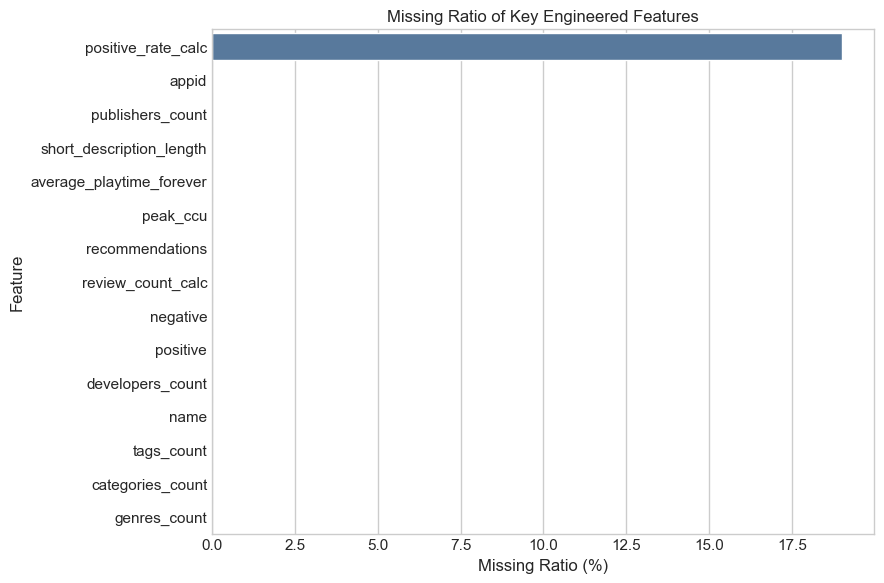

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/06_key_feature_missing_ratio.png


In [8]:
key_feature_cols = [
    "appid", "name", "release_date", "release_year", "price", "is_free", "platform_count",
    "genres_count", "categories_count", "tags_count", "developers_count", "publishers_count",
    "positive", "negative", "review_count_calc", "positive_rate_calc", "recommendations", "peak_ccu",
    "average_playtime_forever", "short_description_length", "about_the_game_length",
]
key_feature_cols = [col for col in key_feature_cols if col in clean_df.columns]

feature_missing = pd.DataFrame({
    "column": key_feature_cols,
    "missing_count": [int(clean_df[col].isna().sum()) for col in key_feature_cols],
    "missing_ratio": [round(clean_df[col].isna().mean() * 100, 2) for col in key_feature_cols],
})
display(feature_missing.sort_values("missing_ratio", ascending=False))

quality_output = pd.concat([
    pd.DataFrame(quality_records),
    feature_missing.rename(columns={"column": "issue", "missing_count": "affected_rows"}).assign(check="missing_key_feature", note="missing ratio recorded"),
], ignore_index=True, sort=False)
quality_output.to_csv(QUALITY_REPORT, index=False)
print("Saved quality report:", QUALITY_REPORT)

plt.figure(figsize=(9, 6))
sns.barplot(data=feature_missing.sort_values("missing_ratio", ascending=False).head(15), x="missing_ratio", y="column", color="#4C78A8")
plt.title("Missing Ratio of Key Engineered Features")
plt.xlabel("Missing Ratio (%)")
plt.ylabel("Feature")
plt.tight_layout()
figure_path = FIGURES_DIR / "06_key_feature_missing_ratio.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", figure_path)

缺失率图表和质量报告可以帮助说明数据清洗不是凭感觉完成的，而是基于可验证的检查结果。

## 9. 保存清洗和特征工程结果

最后，将清洗后的数据保存为 Parquet，作为后续 Notebook 的主要输入。同时保存一个 CSV 样本，方便快速查看。

In [9]:
# Parquet 不适合直接保存 Python list 对象，这里把 list 字段转换为分隔字符串保留信息
save_df = clean_df.copy()
for col in save_df.columns:
    if col.endswith("_list"):
        save_df[col] = save_df[col].apply(lambda items: "|".join(items) if isinstance(items, list) else "")

save_df.to_parquet(FEATURE_PARQUET, index=False)
save_df.head(1000).to_csv(FEATURE_CSV, index=False)

print("Saved feature parquet:", FEATURE_PARQUET)
print("Feature parquet size MB:", round(FEATURE_PARQUET.stat().st_size / (1024 ** 2), 2))
print("Saved feature sample CSV:", FEATURE_CSV)
print("Saved dataframe shape:", save_df.shape)

# 验证可以重新读取
check_df = pd.read_parquet(FEATURE_PARQUET, columns=["appid", "name", "release_year", "price", "review_count_calc", "positive_rate_calc"])
display(check_df.head())

Saved feature parquet: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_march2025_features.parquet
Feature parquet size MB: 102.25
Saved feature sample CSV: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_march2025_features_sample.csv
Saved dataframe shape: (89618, 63)


,appid,name,release_year,price,review_count_calc,positive_rate_calc
0,730,Counter-Strike 2,2012,0.00,8615921,86.825460
1,578080,PUBG: BATTLEGROUNDS,2017,0.00,2512396,59.224740
2,570,Dota 2,2013,0.00,2449800,81.576537
3,271590,Grand Theft Auto V Legacy,2015,0.00,1969962,87.308791
4,359550,Tom Clancy's Rainbow Six® Siege,2015,3.99,1371209,84.069095


## 10. 本 Notebook 小结

本 Notebook 完成了 Steam 主分析数据的清洗和基础特征工程：统一字段名、转换数值和时间字段、检查重复与异常、处理多标签字段、构造价格/平台/评论/热度/文本相关特征，并保存为 Parquet 文件。

后续 Notebook 可以直接读取 `data/processed/steam_march2025_features.parquet`，围绕 Steam 市场结构、玩家反馈和热度机制继续分析。